In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.5
Plasticnet version  0.1.14
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
# cleanest version of the deficit
mu_c=0
sigma_c=0
mu_r=0
sigma_r=0
blur=2

# take about 3 hours to do a full set of sims

base_sim_dir=f"sims-2025-06-24 mu_c {mu_c} sigma_c {sigma_c} mu_r {mu_r} sigma_r {sigma_r} blur {blur}"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)
savepath=base_sim_dir

sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2


In [4]:
def deficit(blur=[4,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=2*8*day,
           save_interval=1*hour):

    
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


In [5]:
def fix(noise=[0.1,0.1],rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,        
           eta=2e-6):
    
    
    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},
                        verbose=False,
                        )
        ]
                     
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)
    
    


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_fix(params,run=True,overwrite=False):
    import plasticnet as pn
    eta,noise,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,blur,total_times,sfname=(
                                params.eta,
                                params.noise,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.blur,
                                params.total_time,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,
                 total_time=total_times[0],
                blur=blur) 

    seq+=fix(
             save_interval=20*minute,number_of_neurons=params.number_of_neurons,
             eta=eta,noise=noise,mu_c=mu_c,sigma_c=sigma_c,
                 total_time=total_times[1],
             mu_r=mu_r,sigma_r=sigma_r)

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
import logging

# Suppress raylet warnings
logging.getLogger("ray").setLevel(logging.ERROR)


In [7]:
number_of_neurons=20
eta=1e-6
number_of_processes=8


ray.init(num_cpus=number_of_processes)


#ray.init(num_cpus=number_of_processes)

2025-06-25 09:51:38,453	INFO worker.py:1888 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.46.0


(raylet) [2025-06-25 09:51:48,442 E 29980 9886537] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_09-51-37_868079_29970 is over 95% full, available space: 136.927 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:51:58,523 E 29980 9886537] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_09-51-37_868079_29970 is over 95% full, available space: 136.935 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:52:08,602 E 29980 9886537] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_09-51-37_868079_29970 is over 95% full, available space: 136.935 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:52:18,689 E 29980 9886537] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_09-51-37_868079_29970 is over 95% full, available space: 136.936 GB; capacity: 3721.87 GB. Object creation wil

In [7]:
func=run_one_continuous_fix

noise_mat=linspace(0,1,11)

all_params=[]
for n,noise in enumerate(noise_mat):
    


    # cleanest version of the deficit -- mu_c=0, sigma_c=0
    p=Struct()
    p.number_of_neurons=number_of_neurons
    p.mu_c=mu_c
    p.sigma_c=sigma_c
    p.mu_r=mu_r
    p.sigma_r=sigma_r
    p.blur=[blur,-1]
    p.noise=(noise,noise)
    p.eta=2e-6
    p.total_time=[8*day*4,8*day*8]
    p.sfname=f'{base_sim_dir}/continuous fix {number_of_neurons} neurons noise {noise:.1f}.asdf'
    
    all_params+=[p]

all_params=to_named_tuple(all_params)  

In [8]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)
    print(sfname)

  0%|          | 0/11 [00:00<?, ?it/s]

sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.0.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.1.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.2.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.3.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.4.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.5.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.6.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.7.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.8.asdf
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.9.asdf
sims-2025-06-24 mu_c

In [9]:
do_params=make_do_params(all_params,verbose=True)

11 sims
[params(number_of_neurons=20, mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, blur=[2, -1], noise=(0.0, 0.0), eta=2e-06, total_time=[2764800, 5529600], sfname='sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.0.asdf', count=0), params(number_of_neurons=20, mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, blur=[2, -1], noise=(0.1, 0.1), eta=2e-06, total_time=[2764800, 5529600], sfname='sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.1.asdf', count=1), params(number_of_neurons=20, mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, blur=[2, -1], noise=(0.2, 0.2), eta=2e-06, total_time=[2764800, 5529600], sfname='sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/continuous fix 20 neurons noise 0.2.asdf', count=2), params(number_of_neurons=20, mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, blur=[2, -1], noise=(0.30000000000000004, 0.30000000000000004), eta=2e-06, total_time=[2764800, 5529600], sfname='sims-2025-06-24 mu_c 0 sigma_c 0 

In [10]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [11]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)


  0%|          | 0/11 [00:00<?, ?it/s]

In [12]:
subResults={}
for params in tqdm(all_params):
    sfname=params.sfname
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    idx1,idx2=[_[1] for _ in R.sequence_index]
    
    subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=params.sfname
    subR.params=params
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
    subR.recovery_rate=(R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1])
    subR.SF_Var_recovery_rate=(R.SF_Var[idx2,:]-R.SF_Var[idx1,:])/(t[idx2]-t[idx1])
    subR.ODI2=R.ODI[idx2,:]
    subR.ODI1=R.ODI[idx1,:]
    
    subResults[params.sfname]=subR


  0%|          | 0/11 [00:00<?, ?it/s]

In [13]:
assert func==run_one_continuous_fix
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    noise=params.noise[1]
    
    subR=subResults[sfname]

    idx0,idx1,idx2=subR.idx
    t=subR.t
    recovery_rate_μ,recovery_rate_σ=μσ(subR.recovery_rate)

    ODI_μ2=subR.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=subR.ODI[idx2,:].std()
    N=subR.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=subR.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=subR.ODI[idx1,:].std()
    N=subR.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)

    SF_Var_recovery_rate_μ,SF_Var_recovery_rate_σ=μσ(subR.SF_Var_recovery_rate)

    
    St+=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SF_Var_recovery_rate_μ,SF_Var_recovery_rate_σ 

noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SF_Var_recovery_rate_μ,SF_Var_recovery_rate_σ=St.arrays()

glasses_result=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SF_Var_recovery_rate_μ,SF_Var_recovery_rate_σ

savevars(f'{base_sim_dir}/full_glasses_results.asdf',
         'subResults','glasses_result','noise_mat',
          'noise','recovery_rate_μ','recovery_rate_σ',
            'ODI_μ1','ODI_σ1','ODI_μ2','ODI_σ2',
          'SF_Var_recovery_rate_μ','SF_Var_recovery_rate_σ')
# savevars(f'{base_sim_dir}/glasses_results.asdf','glasses_result')    

  0%|          | 0/11 [00:00<?, ?it/s]

Saving sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/full_glasses_results.asdf...done.


Found ['subResults', 'glasses_result', 'noise_mat', 'noise', 'recovery_rate_μ', 'recovery_rate_σ', 'ODI_μ1', 'ODI_σ1', 'ODI_μ2', 'ODI_σ2', 'SF_Var_recovery_rate_μ', 'SF_Var_recovery_rate_σ']
0.010163495067842138 0.012062079230243503
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/glasses_treatment.pdf
Manuscript/resources/sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2-glasses_treatment.png
Manuscript/resources/sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2-glasses_treatment.svg
sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2/glasses_treatment.pdf
Manuscript/resources/sims-2025-06-24 mu_c 0 sigma_c 0 mu_r 0 sigma_r 0 blur 2-glasses_treatment.pdf


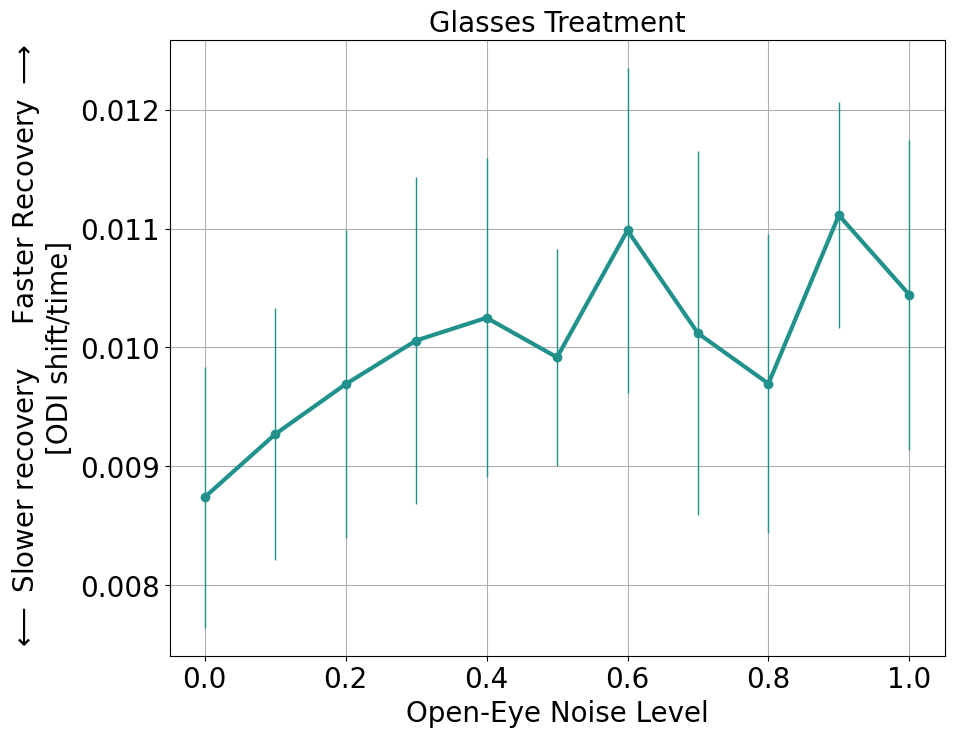

In [14]:
loadvars(base_sim_dir+'/full_glasses_results.asdf')

import cycler
colormap=cm.viridis

n = 5
#colormap=cm.Blues
#color = colormap(np.linspace(1, 0,int(1.2*n)))

colormap=cm.viridis
color = colormap(np.linspace(0, 1,n))

glasses_plot_color=cm.viridis(np.linspace(0, 1,5))[2]

#noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,,SF_Var_recovery_rate_μ,SF_Var_recovery_rate_σ =glasses_result        

glasses_μ=-recovery_rate_μ
glasses_σ=2*recovery_rate_σ

# best case
idx=argmax(glasses_μ)
max_glasses=glasses_μ[idx]+glasses_σ[idx]
min_glasses=glasses_μ[idx]-glasses_σ[idx]
print(min_glasses,max_glasses)


errorbar(noise,-recovery_rate_μ,yerr=2*recovery_rate_σ,elinewidth=1,fmt='o-',color=color[2]) # positive = recovery
ylabel(r'$\longleftarrow$ Slower recovery     Faster Recovery $\longrightarrow$'+"\n[ODI shift/time]")
xlabel('Open-Eye Noise Level')
title('Glasses Treatment')

sfname=f"{savepath}/glasses_treatment.pdf"
print(sfname)
savefig(sfname)
